In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("merged_all_features.csv")
print(df.head(),"\n",df.describe(),"\n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 0 to 5820
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   doi             5820 non-null   object 
 1   title           5821 non-null   object 
 2   year            5821 non-null   int64  
 3   citations       5821 non-null   int64  
 4   is_oa           5821 non-null   bool   
 5   type            5821 non-null   object 
 6   source_journal  5821 non-null   object 
 7   abstract        5821 non-null   object 
 8   ASL             5805 non-null   float64
 9   MWL             5821 non-null   float64
 10  LD              5821 non-null   float64
 11  LC              5821 non-null   float64
 12  JD              5821 non-null   float64
 13  HD              5821 non-null   float64
 14  NCC             5821 non-null   float64
 15  ncc_group       5821 non-null   object 
 16  mean_citations  5821 non-null   float64
dtypes: bool(1), float64(8), int64(2),

In [3]:
correlationmatrix=df[['MWL','LC','LD','ASL','JD','HD','NCC']].corr()
print(correlationmatrix)

          MWL        LC        LD       ASL        JD        HD       NCC
MWL  1.000000  0.288704  0.298990 -0.011741  0.166266  0.032690  0.071510
LC   0.288704  1.000000  0.372007 -0.150324  0.314458  0.086718 -0.025405
LD   0.298990  0.372007  1.000000 -0.240065  0.137530 -0.155426 -0.018730
ASL -0.011741 -0.150324 -0.240065  1.000000 -0.042745  0.054887  0.014479
JD   0.166266  0.314458  0.137530 -0.042745  1.000000 -0.065619 -0.011532
HD   0.032690  0.086718 -0.155426  0.054887 -0.065619  1.000000  0.009475
NCC  0.071510 -0.025405 -0.018730  0.014479 -0.011532  0.009475  1.000000


相关性测试的结果和基线测试一致，在扩大化测试结束后需要考虑：
1. 换用更具代表性的文体特征，这方面可以去咨询左老师
2. 选用多元回归分析，所以可以暂时跳过一元线性回归

c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=23.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=23.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=23.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Win

最优的k值是 2


c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=23.
  warnings.warn(


K-Means的轮廓系数得分是； 0.18369467426476968


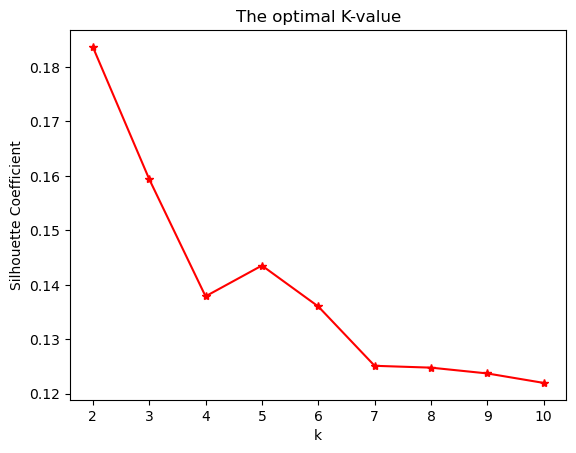

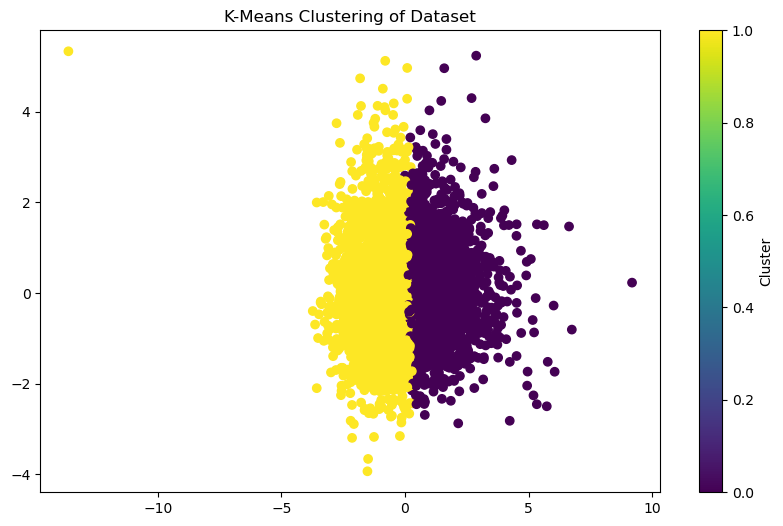

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_k = df[["MWL","LC","LD","ASL","JD","HD"]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_k)

s_scores = []
k_values = range(2,11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    s_scores.append(silhouette_score(X_scaled,kmeans.labels_))
plt.plot(k_values,s_scores,'r*-')
plt.xlabel('k')
plt.ylabel('Silhouette Coefficient')
plt.title('The optimal K-value')

optimal_k = k_values[s_scores.index(max(s_scores))]
print("最优的k值是",optimal_k)

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)

print("K-Means的轮廓系数得分是；",silhouette_score(X_scaled, kmeans_labels))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0],X_pca[:,1], c=kmeans_labels, cmap="viridis")
plt.title('K-Means Clustering of Dataset')
plt.colorbar(label="Cluster")
plt.show()

  分类树：预测 NCC 高/低影响力
              precision    recall  f1-score   support

           0       0.66      0.96      0.78       756
           1       0.46      0.06      0.10       405

    accuracy                           0.65      1161
   macro avg       0.56      0.51      0.44      1161
weighted avg       0.59      0.65      0.54      1161

Accuracy: 0.6477


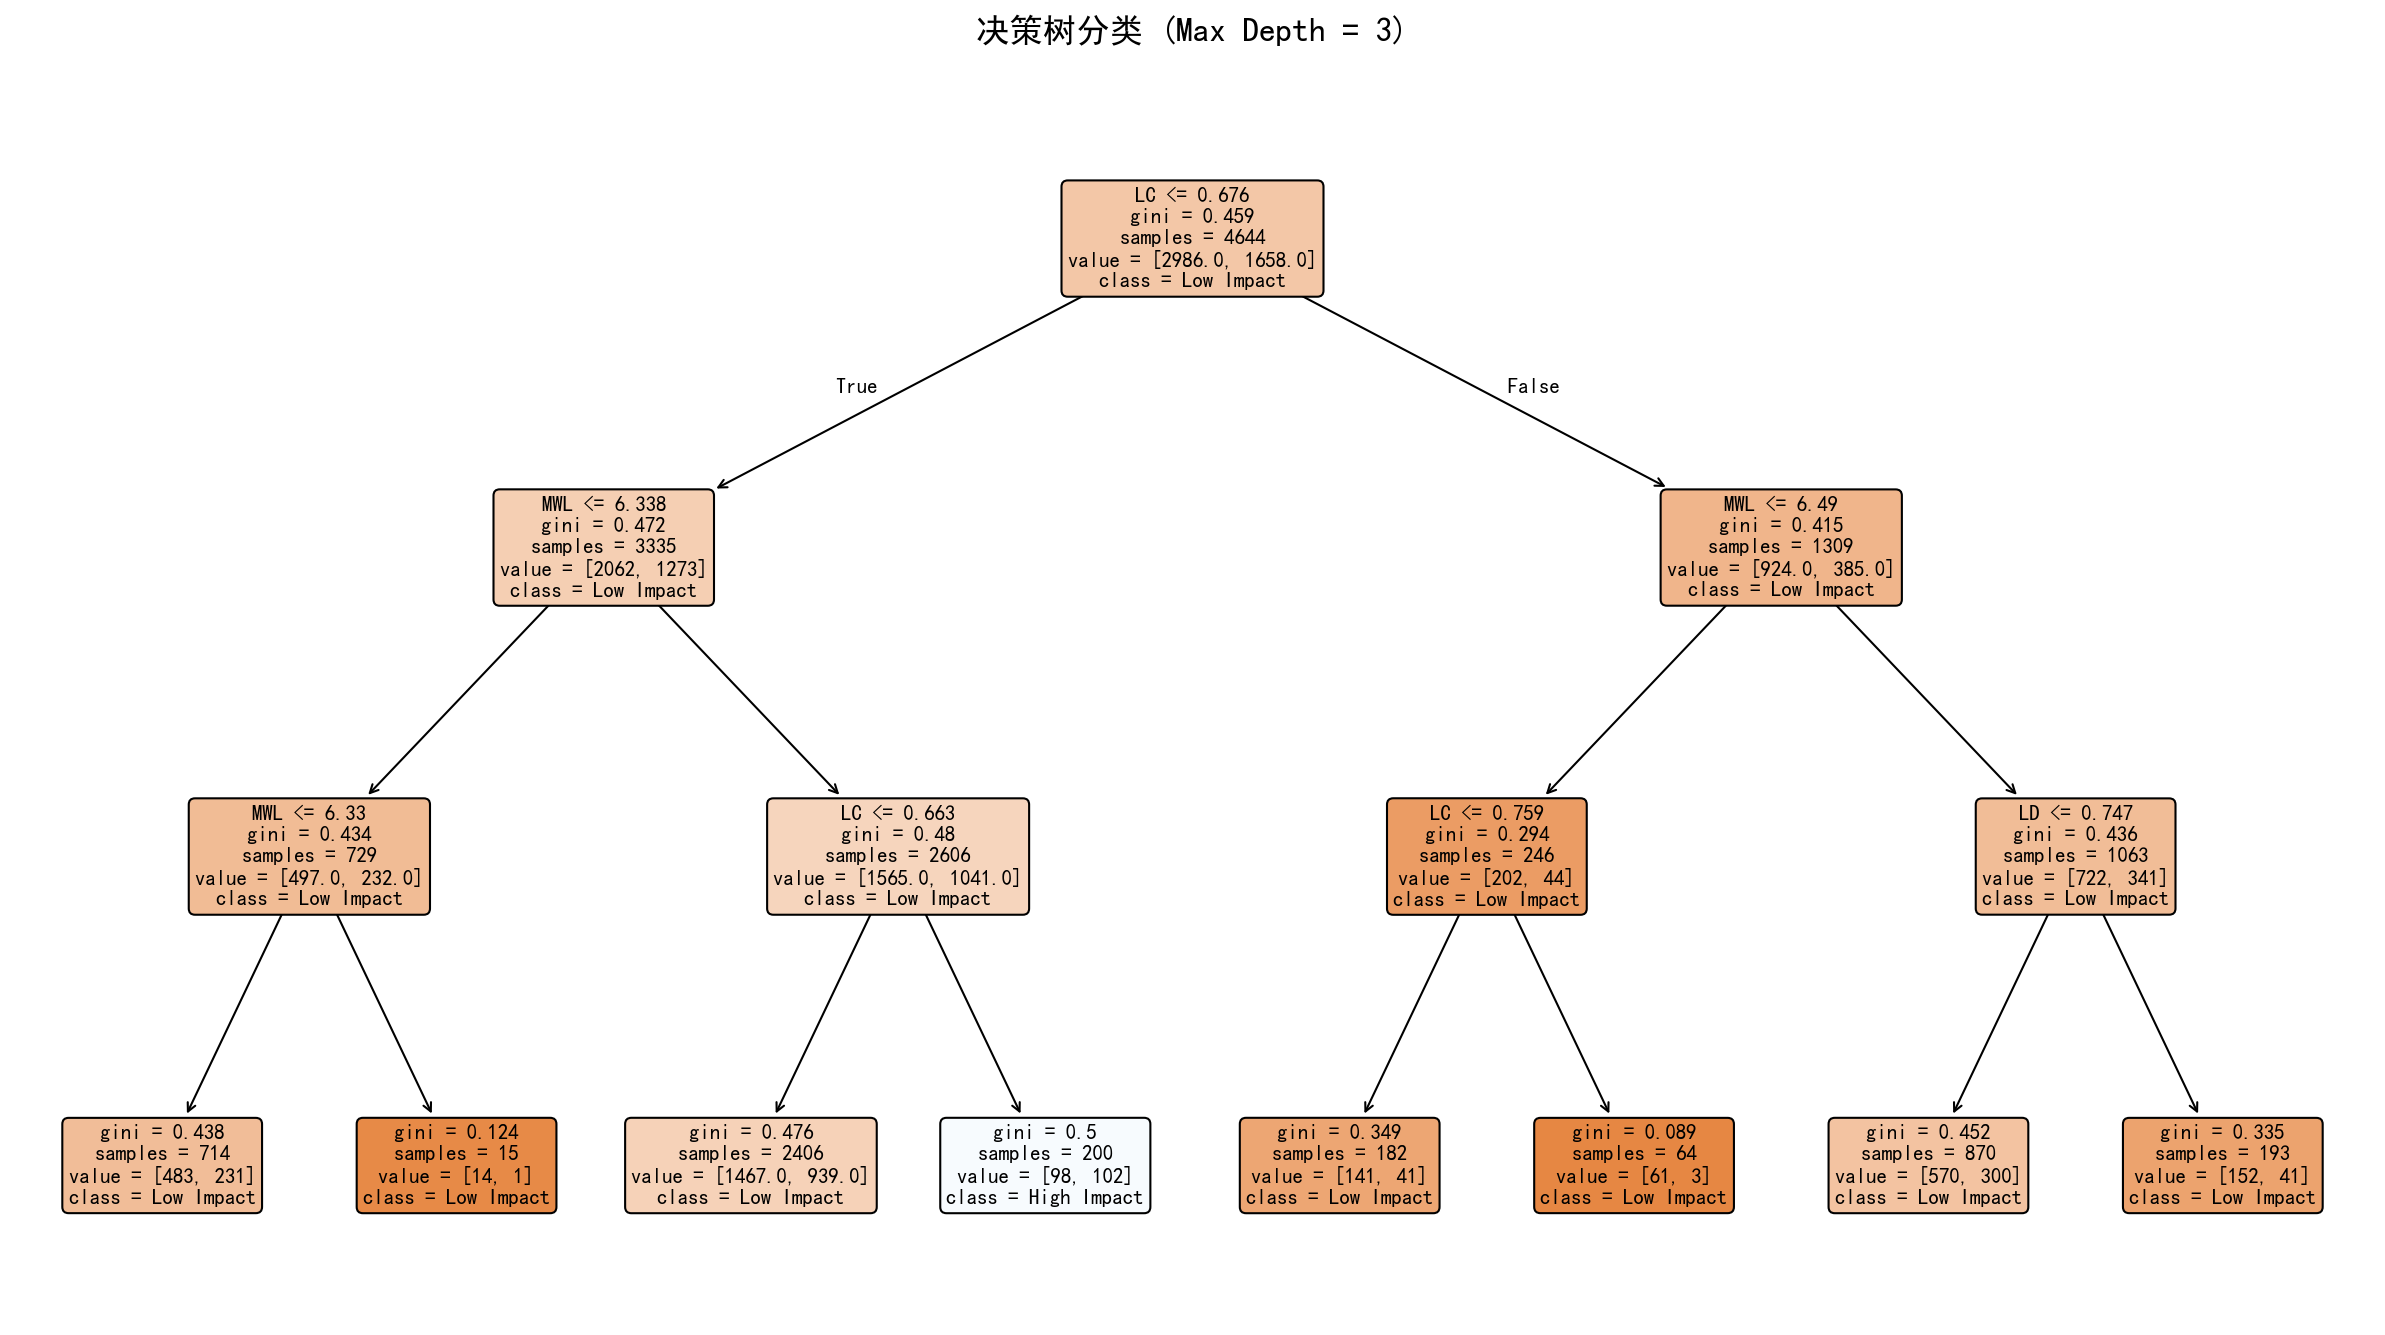

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import classification_report, accuracy_score, r2_score

df['high_impact'] = (df['NCC'] >= 1.0).astype(int)

cols = ['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']

# 【修改1】添加 dropna() 处理 ASL 的 16 个缺失值，并用 .loc 对齐 X 和 y（原：未处理缺失值）
valid_idx = df[cols].dropna().index
X = df.loc[valid_idx, cols]
y = df.loc[valid_idx, 'high_impact']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("=" * 60)
print("  分类树：预测 NCC 高/低影响力")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(16, 9), dpi=150)
plot_tree(clf, feature_names=cols, class_names=['Low Impact', 'High Impact'],
          filled=True, rounded=True, fontsize=10)
plt.title('决策树分类 (Max Depth = 3)', fontsize=16, pad=20)
plt.tight_layout()
# 【修改2】添加 .png 扩展名（原：无扩展名，文件无法预览）
plt.savefig('决策树_classification.png', dpi=300, bbox_inches='tight')
plt.show()

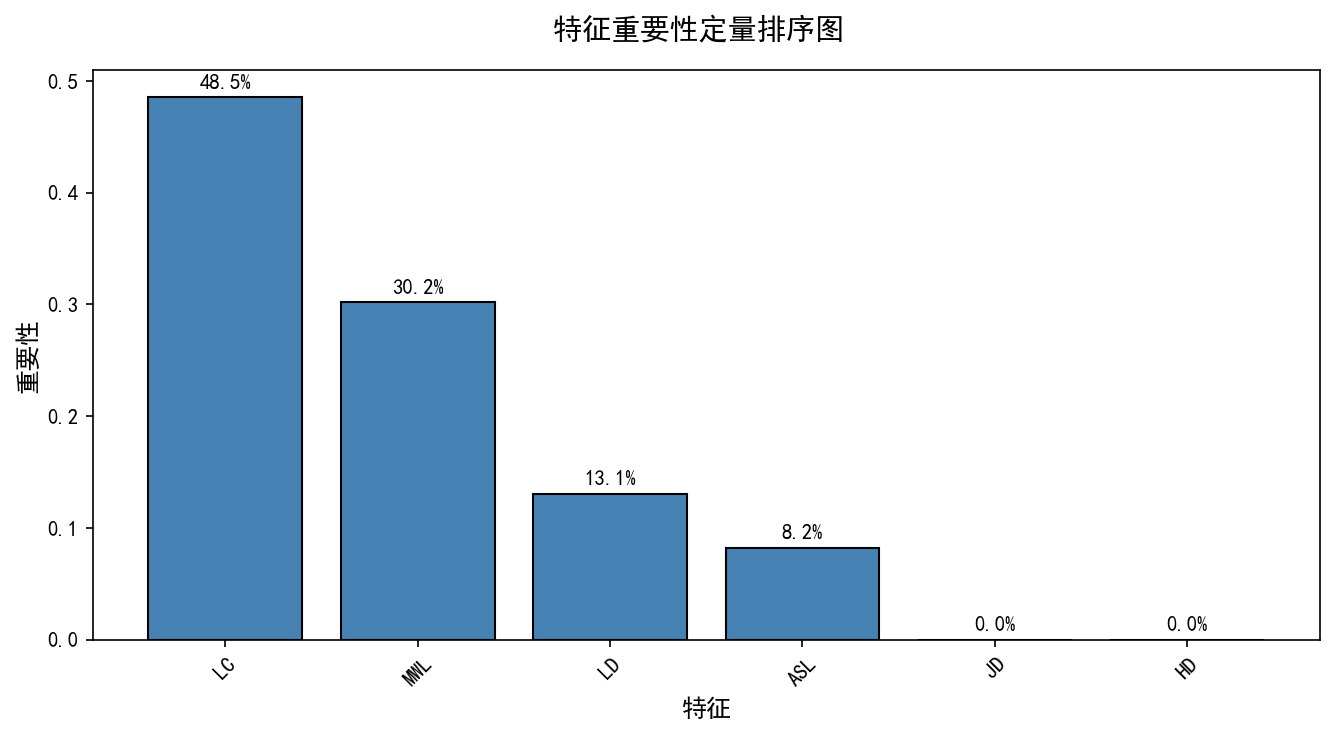

In [8]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
cols=['MWL', 'LC', 'LD', 'ASL', 'JD', 'HD']
X=df[cols]
y=df['high_impact']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
imp_series = pd.Series(importances, index=cols).sort_values(ascending=False)
plt.figure(figsize=(9, 5), dpi=150)
plt.bar(imp_series.index, imp_series.values, align="center", color='steelblue', edgecolor='black')
plt.title('特征重要性定量排序图 ', fontsize=14, pad=15)
plt.xlabel('特征', fontsize=12)
plt.ylabel('重要性', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(imp_series.values):
    plt.text(i, v + 0.005, f"{v:.1%}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('特征重要性', dpi=300, bbox_inches='tight')

In [9]:
print(f'LC 阈值: {clf.tree_.threshold[0]:.4f}')
print(f'LC 描述: mean={df["LC"].mean():.3f}, median={df["LC"].median():.3f}')
print(f'各期刊 LC 均值:')
print(df.groupby('source_journal')['LC'].mean().sort_values())

LC 阈值: 0.7529
LC 描述: mean=0.628, median=0.624
各期刊 LC 均值:
source_journal
Anti-Corrosion Methods and Materials                                                                                   0.559920
CORROSION                                                                                                              0.618378
Corrosion and Materials Degradation                                                                                    0.634813
Materials and Corrosion                                                                                                0.636923
Corrosion Engineering Science and Technology The International Journal of Corrosion Processes and Corrosion Control    0.644272
Corrosion Science                                                                                                      0.685899
Name: LC, dtype: float64


LC分裂阈值高于各期刊均值，说明决策树并非按期刊分类，但较低的accuracy还是证明决策树模型相对无效